# NESTML MAT Validation Script 

This script is used to validate Yamauchi et al., 2011 MAT neuronal figures and to test the trace_plotter utility function.

In this script we will use a small, reusable utility script for plotting for the following NEST neuronal characteristics:

- Spike : Vertical tick marking the moment of the AP
- θ(t) : Dynamic threshold
- V(t) : Voltage
- dV/dt : The instantaneous rate of change of V (raw derivative signal that feeds the adaptation).
- β∫K(s)·dV/dt(t−s) ds : A convolution of dV/dt with a kernel K(s), scaled by β. This is the filtered/smoothed adaptation signal
- I(t) : The injected input current (step stimulus driving the neuron

An example plot, with the variable discussed above is shown below.  



<img src="images/example_plot.png" width="400" height="300">

In [1]:
# testing imports and mamba env 
import nest
import pynestml
import sys
import numpy as np
from trace_plotter import TracePlotter
from pynestml.codegeneration.nest_code_generator_utils import NESTCodeGeneratorUtils


             -- N E S T --

 Copyright (C) 2004 The NEST Initiative

 Version: 3.9.0-post0.dev14
 Built  : Jul 16 2026 16:13:29

 This program is provided AS IS and comes with NO WARRANTY.
 See the file LICENSE for details.

 Problems or suggestions?
   Visit https://www.nest-simulator.org

 Type 'nest.help()' to find out more about NEST.



In [2]:
# importing and building the MAT neuron from nestml, for a conda-forge NEST install, NEST lives directly in the env prefix
nest_path = sys.prefix
print(repr(nest_path))          #  sanity check, seeing where nest_path is derived from 

module_name, neuron_model_name = NESTCodeGeneratorUtils.generate_code_for(
    "neurons_nestml/mat2_psc_exp_neuron.nestml",
    module_name="nestml_mat_module",   # fix the name explicitly so it's predictable
    logging_level="INFO",
)
# info   
print("module:", module_name)
print("neuron model:", neuron_model_name)

'/Users/angusgray/Desktop/JSC/nest-simulator/mamba'


[1,GLOBAL, INFO]: List of files that will be processed:
[2,GLOBAL, INFO]: /Users/angusgray/Desktop/JSC/nest-simulator/visualisation/neurons_nestml/mat2_psc_exp_neuron.nestml
[3,GLOBAL, INFO]: Target platform code will be generated in directory: "/Users/angusgray/Desktop/JSC/nest-simulator/visualisation/target"
[4,GLOBAL, INFO]: Target platform code will be installed in directory: "/var/folders/jk/36jftn6s3yz6ks1zj2zdlry40000gn/T/nestml_target_b0hkg6xe"

             -- N E S T --

 Copyright (C) 2004 The NEST Initiative

 Version: 3.9.0-post0.dev14
 Built  : Jul 16 2026 16:13:29

 This program is provided AS IS and comes with NO WARRANTY.
 See the file LICENSE for details.

 Problems or suggestions?
   Visit https://www.nest-simulator.org

 Type 'nest.help()' to find out more about NEST.

[5,GLOBAL, INFO]: The NEST Simulator version was automatically detected as: main
[6,GLOBAL, INFO]: Given template root path is not an absolute path. Creating the absolute path with default templates d

INFO:root:Analysing input:
INFO:root:{
    "dynamics": [
        {
            "expression": "V_m' = (-(V_m - E_L)) / tau_m + ((unit_psc * (I_kernel_exc__X__exc_spikes - I_kernel_inh__X__inh_spikes)) + I_e + I_stim) / C_m",
            "initial_values": {
                "V_m": "E_L"
            }
        },
        {
            "expression": "refr_t' = (-1000.0) * 1.0 / 1000.0",
            "initial_values": {
                "refr_t": "0"
            }
        },
        {
            "expression": "I_kernel_inh__X__inh_spikes = exp(-t / tau_syn_inh)",
            "initial_values": {}
        },
        {
            "expression": "I_kernel_exc__X__exc_spikes = exp(-t / tau_syn_exc)",
            "initial_values": {}
        }
    ],
    "options": {
        "output_timestep_symbol": "__h",
        "simplify_expression": "sympy.logcombine(sympy.powsimp(sympy.expand(expr)))"
    },
    "parameters": {
        "C_m": "100",
        "E_L": "(-70)",
        "I_e": "0",
        "alpha_1"

[13,GLOBAL, INFO]: Starting code generation for model "mat2_psc_exp_neuron_nestml"
[14,mat2_psc_exp_neuron_nestml, INFO, [57:0;126:0]]: Starts processing of the model "mat2_psc_exp_neuron_nestml"
[15,GLOBAL, INFO]: Rendering template /Users/angusgray/Desktop/JSC/nest-simulator/visualisation/target/mat2_psc_exp_neuron_nestml.cpp
[16,GLOBAL, INFO]: Rendering template /Users/angusgray/Desktop/JSC/nest-simulator/visualisation/target/mat2_psc_exp_neuron_nestml.h
[17,mat2_psc_exp_neuron_nestml, INFO, [57:0;126:0]]: Successfully generated code for the model: "mat2_psc_exp_neuron_nestml" in: "/Users/angusgray/Desktop/JSC/nest-simulator/visualisation/target" !
[18,GLOBAL, INFO]: Rendering template /Users/angusgray/Desktop/JSC/nest-simulator/visualisation/target/CMakeLists.txt
[19,GLOBAL, INFO]: Rendering template /Users/angusgray/Desktop/JSC/nest-simulator/visualisation/target/nestml_mat_module.h
[20,GLOBAL, INFO]: Rendering template /Users/angusgray/Desktop/JSC/nest-simulator/visualisation/tar

In [32]:
nest.ResetKernel()
nest.set_verbosity("M_ERROR")
nest.SetKernelStatus({"resolution": 0.1, "local_num_threads": 1, "rng_seed": 12345})

nest.Install(module_name)
print("Loaded:", neuron_model_name in nest.Models())

neuron = nest.Create(neuron_model_name)

# depolarising current amplitude start/stop
dc_amplitude = 500
dc_start = 300.0
dc_stop = 1000.0

dc = nest.Create("dc_generator", {
    "amplitude": dc_amplitude,
    "start": dc_start,
    "stop": dc_stop
})

nest.Connect(dc, neuron)

voltmeter = nest.Create("voltmeter", {"interval": 0.1, "record_from": ["V_m", "V_th_alpha_1", "V_th_alpha_2"]})
nest.Connect(voltmeter, neuron)

spikedetector = nest.Create("spike_recorder")
nest.Connect(neuron, spikedetector)

nest.Simulate(1000.0)

events = voltmeter.get("events")
t = events["times"]
V = events["V_m"]
spike_times = spikedetector.get("events")["times"]

params = nest.GetDefaults(neuron_model_name)
E_L = params["E_L"]
omega = params["omega"]

I = np.zeros_like(t)
I[(t >= dc_start) & (t <= dc_stop)] = dc_amplitude

spike_times = spikedetector.get("events")["times"]

theta = E_L + omega + events["V_th_alpha_1"] + events["V_th_alpha_2"]

spike_times = spikedetector.get("events")["times"]

Loaded: True


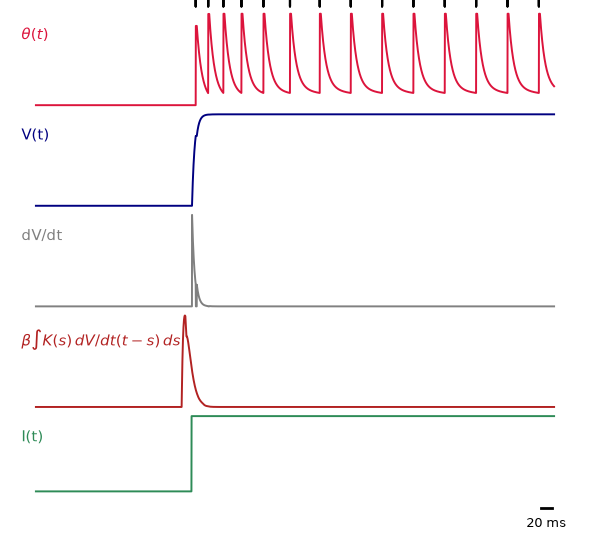

In [33]:
dVdt = np.gradient(V, t)

# reconstruct the β∫K(s)dV/dt(t-s)ds convolution term for display purposes
dt = t[1] - t[0]
tau_k = 8.0  # ms, matches whatever adaptation kernel your model uses
kernel = np.exp(-np.arange(0, 40, dt) / tau_k)
kernel /= kernel.sum()
conv = np.convolve(dVdt, kernel, mode="same")

tp = TracePlotter(t, time_unit="ms")

for st in spike_times:
    tp.add_spike(st)
    
tp.add_trace("theta", theta, color="crimson", label=r"$\theta(t)$")
tp.add_trace("V", V, color="navy", label="V(t)")
tp.add_trace("dVdt", dVdt, color="gray", label="dV/dt")
tp.add_trace("conv", conv, color="firebrick", label=r"$\beta\int K(s)\,dV/dt(t-s)\,ds$")
tp.add_trace("I", I, color="seagreen", label="I(t)")
fig, axes = tp.plot(scalebar_ms=20)